# The Renewal Threshold: Predicting PG Resident Renewal Intention Using Behavioral and Service-Experience Analytics

**Business Analytics individual case study**  
**Analytical file:** `data/synthetic_survey_10000.csv` (10,000 synthetic records).  

> Provenance: The supplied analytical file is synthetic and was accepted by the faculty as the case study dataset. No original raw Google Forms export or approved proposal document was available in the working files. A separate 128-row seed file existed in a neighboring folder, but this notebook does not use it: the requested analysis is based on the supplied 10,000-row dataset. Faculty acceptance establishes this file as the approved analytical dataset; source-to-synthetic fidelity and original cleaning decisions still cannot be independently audited from the materials available here. These records are not 10,000 real residents.

This notebook compares amenity/security ratings with service-experience variables for **definite stated intention** only: Yes = 1 and No = 0. â€œMaybeâ€ is excluded from binary prediction and reported separately. This explicit choice preserves the survey's three-category response without pretending uncertainty means non-renewal.

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, chi2_contingency
from sklearn.model_selection import RepeatedStratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import make_scorer, balanced_accuracy_score, f1_score, roc_auc_score, average_precision_score
SEED=42
DATA=Path('data/synthetic_survey_10000.csv')
df=pd.read_csv(DATA)
print('Shape:',df.shape,'\nColumns:',list(df.columns),'\nMissing cells:',int(df.isna().sum().sum()),'\nExact duplicate rows:',int(df.duplicated().sum()))
df.head()

Shape: (10000, 12) 
Columns: ['OCCUPATION', 'Current monthly rent', 'How long have you stayed at this PG? (in months)', 'Overall, how would you rate the physical amenities (room, furniture, Wi-Fi, food) at this PG?', 'How would you rate the security of the PG?', 'When you last raised a complaint, how long did it take to resolve?', 'How many complaints have you raised in the last 3 months?', "Is your security deposit fully refundable based on what you've seen/heard from others who left?", 'Do you feel your rent is fair compared to similar PGs nearby?', 'Overall, how satisfied are you with this PG?', 'Do you intend to renew/continue your stay at this PG beyond your current term?', "What's the single biggest reason for your answer above?"] 
Missing cells: 0 
Exact duplicate rows: 69


,OCCUPATION,Current monthly rent,How long have you stayed at this PG? (in months),"Overall, how would you rate the physical amenities (room, furniture, Wi-Fi, food) at this PG?",How would you rate the security of the PG?,"When you last raised a complaint, how long did it take to resolve?",How many complaints have you raised in the last 3 months?,Is your security deposit fully refundable based on what you've seen/heard from others who left?,Do you feel your rent is fair compared to similar PGs nearby?,"Overall, how satisfied are you with this PG?",Do you intend to renew/continue your stay at this PG beyond your current term?,What's the single biggest reason for your answer above?
0,WORKING PROFESSIONAL,5000,7.4,5,3,same day,2,"Yes, straightforward",fair,5,Yes,The rent is reasonable and the facilities are ...
1,STUDENT,5000,10.6,4,4,no complaints raised,1,"Yes, straightforward",overpriced,4,Maybe,"The location is good, but the rent could be be..."
2,WORKING PROFESSIONAL,15000,1.3,5,3,same day,1,Not sure,fair,5,Yes,The location is convenient and the overall exp...
3,WORKING PROFESSIONAL,5000,3.3,3,4,no complaints raised,2,"Yes, straightforward",fair,5,Yes,The PG is comfortable and well maintained.
4,WORKING PROFESSIONAL,18000,22.8,4,5,no complaints raised,1,Not sure,underpriced,5,No,The food quality is not satisfactory.


## 1â€“2. Problem, objectives and dataset description

**Problem.** PG operators need to understand which reported experience dimensions align with residentsâ€™ definite intention to continue their stay. The case compares conventional amenities and security with complaint handling, complaint volume, deposit refund transparency, and perceived rent fairness.

**Objectives.** (1) Describe the supplied synthetic dataset and stated renewal categories. (2) Compare association and out-of-fold predictive performance for amenity-only, service-only and combined feature blocks. (3) Translate supported patterns into cautious operational recommendations.

The available file has 10,000 rows and 12 survey-like fields. Its exact upstream collection, synthesis code and original records are not part of this project directory. Findings below describe this file only. â€œBiggest reasonâ€ is excluded from prediction because it may directly encode respondentsâ€™ stated rationale; overall satisfaction is kept separate and tested only as an additional proxy/leakage experiment.

## 3. Preparation and exploratory analysis

The supplied data is already numeric or categorical and contains no missing cells/duplicate rows at load. We retain the original columns, derive readable analysis variables, preserve all Yes/Maybe/No categories descriptively, and use Yes/No rows for binary models. We do not claim independent respondent identities.

In [2]:
# Normalize into analysis columns; retain raw frame unchanged.
work=pd.DataFrame({
 'occupation':df['OCCUPATION'].astype('string').str.strip(),
 'rent':pd.to_numeric(df['Current monthly rent'],errors='coerce'),
 'stay_months':pd.to_numeric(df.iloc[:,2],errors='coerce'),
 'amenities':pd.to_numeric(df.iloc[:,3],errors='coerce'),
 'security':pd.to_numeric(df.iloc[:,4],errors='coerce'),
 'resolution_raw':df.iloc[:,5].astype('string').str.strip().str.lower(),
 'complaints':pd.to_numeric(df.iloc[:,6],errors='coerce'),
 'deposit_raw':df.iloc[:,7].astype('string').str.strip().str.lower(),
 'fairness_raw':df.iloc[:,8].astype('string').str.strip().str.lower(),
 'satisfaction':pd.to_numeric(df.iloc[:,9],errors='coerce'),
 'renewal_raw':df.iloc[:,10].astype('string').str.strip().str.lower(),
 'reason':df.iloc[:,11].astype('string')})
print('Renewal distribution:')
print(work.renewal_raw.value_counts(dropna=False).to_frame('n').assign(percent=lambda x:100*x.n/len(work)).round(2))
print('Numeric ranges:')
work[['rent','stay_months','amenities','security','complaints','satisfaction']].describe().T

Renewal distribution:
                n  percent
renewal_raw               
yes          4706    47.06
maybe        4194    41.94
no           1100     11.0
Numeric ranges:


,count,mean,std,min,25%,50%,75%,max
rent,10000.0,11065.35000,5544.675709,5000.0,5000.0,10500.0,18000.0,18000.0
stay_months,10000.0,16.84775,11.612531,1.0,6.3,16.4,26.3,36.0
amenities,10000.0,3.99040,0.795721,1.0,3.0,4.0,5.0,5.0
security,10000.0,4.12200,0.723580,1.0,4.0,4.0,5.0,5.0
complaints,10000.0,1.14200,1.062332,0.0,0.0,1.0,2.0,6.0
satisfaction,10000.0,4.55860,0.636873,2.0,4.0,5.0,5.0,5.0


In [3]:
# Recoding preserves the distinction between no complaint and unresolved complaint.
resmap={'same day':0,'few days':1,'over a week':2,'never resolved':3,'no complaints raised':np.nan}
work['resolution']=work.resolution_raw.map(resmap)
work['no_complaint_raised']=(work.resolution_raw=='no complaints raised').astype(int)
depmap={'yes, straightforward':0,'not sure':1,'disputes are common':2}
work['deposit_concern']=work.deposit_raw.map(depmap)
fairmap={'underpriced':0,'fair':1,'overpriced':2}
work['rent_unfairness']=work.fairness_raw.map(fairmap)
# Complaint count is retained as numeric as recorded. A semantic consistency check is descriptive only.
work['complaint_consistency']=np.select([((work.complaints==0)&(work.no_complaint_raised==0)),((work.complaints>0)&(work.no_complaint_raised==1))],['count zero / complaint indicated','positive count / no-complaint indicated'],default='not flagged')
print('Complaint/resolution consistency flags:')
print(work.complaint_consistency.value_counts())
print('Unmapped response counts:',{c:int(work[c].isna().sum()) for c in ['resolution','deposit_concern','rent_unfairness']})


Complaint/resolution consistency flags:
complaint_consistency
not flagged                                5694
count zero / complaint indicated           2273
positive count / no-complaint indicated    2033
Name: count, dtype: int64
Unmapped response counts: {'resolution': 2941, 'deposit_concern': 0, 'rent_unfairness': 0}


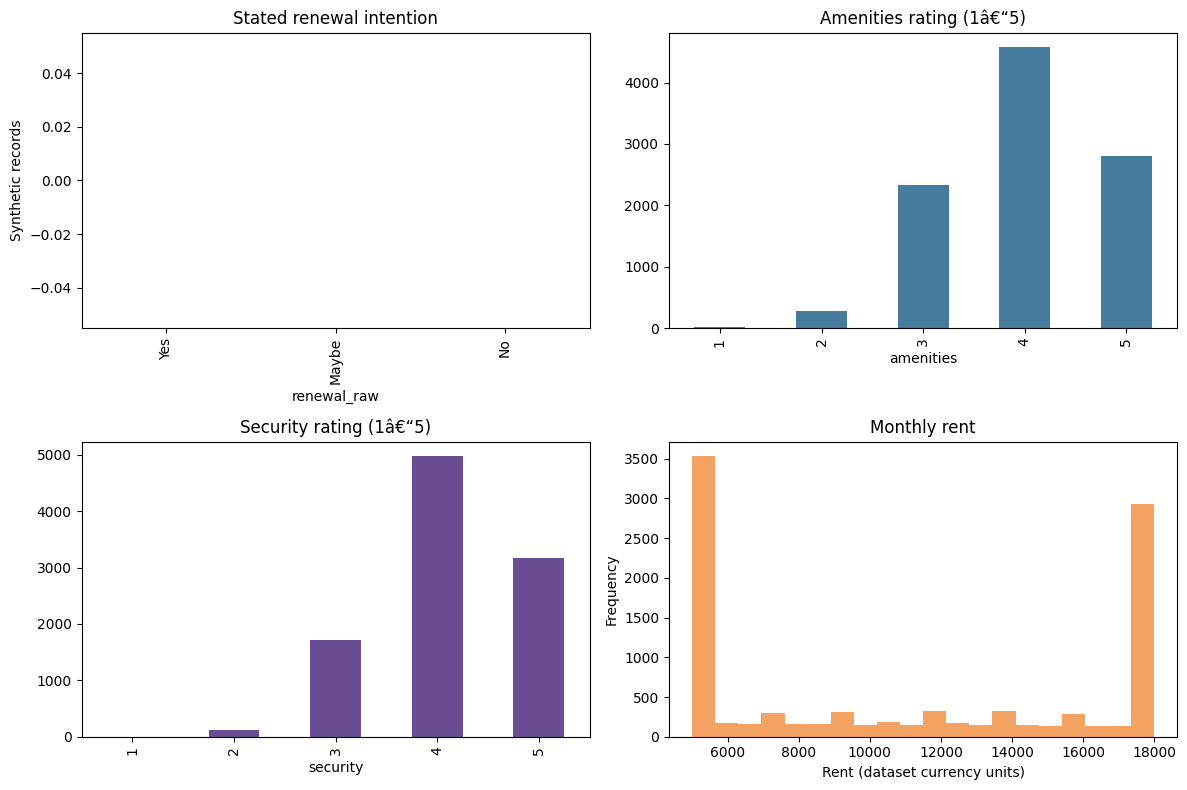

In [4]:
# Simple distribution charts
fig,axs=plt.subplots(2,2,figsize=(12,8))
work.renewal_raw.value_counts().reindex(['Yes','Maybe','No']).plot.bar(ax=axs[0,0],color=['#2a9d8f','#e9c46a','#e76f51']); axs[0,0].set_title('Stated renewal intention'); axs[0,0].set_ylabel('Synthetic records')
work.amenities.value_counts().sort_index().plot.bar(ax=axs[0,1],color='#457b9d'); axs[0,1].set_title('Amenities rating (1â€“5)')
work.security.value_counts().sort_index().plot.bar(ax=axs[1,0],color='#6a4c93'); axs[1,0].set_title('Security rating (1â€“5)')
work.rent.plot.hist(bins=20,ax=axs[1,1],color='#f4a261'); axs[1,1].set_title('Monthly rent'); axs[1,1].set_xlabel('Rent (dataset currency units)')
plt.tight_layout(); plt.show()

In [5]:
def rate_table(feature):
 return work.groupby(feature,dropna=False).renewal_raw.apply(lambda s: pd.Series({'n':len(s),'Yes %':100*(s=='yes').mean(),'Maybe %':100*(s=='maybe').mean(),'No %':100*(s=='no').mean()})).unstack().round(1)
for f in ['amenities','security','complaints','resolution_raw','deposit_raw','fairness_raw','satisfaction','occupation']:
 print('\nRenewal by',f); display(rate_table(f))


Renewal by amenities


,n,Yes %,Maybe %,No %
amenities,,,,
1,11.0,27.3,63.6,9.1
2,275.0,32.4,46.5,21.1
3,2323.0,38.2,46.6,15.2
4,4581.0,47.6,41.5,10.9
5,2810.0,54.9,38.3,6.8



Renewal by security


,n,Yes %,Maybe %,No %
security,,,,
1,1.0,0.0,0.0,100.0
2,121.0,32.2,42.1,25.6
3,1713.0,40.6,43.0,16.4
4,4987.0,46.4,42.9,10.7
5,3178.0,52.2,39.9,7.9



Renewal by complaints


...

,n,Yes %,Maybe %,No %
fairness_raw,,,,
fair,9067.0,49.5,41.0,9.5
overpriced,317.0,20.2,56.2,23.7
underpriced,616.0,24.5,48.7,26.8



Renewal by satisfaction


,n,Yes %,Maybe %,No %
satisfaction,,,,
2,46.0,0.0,15.2,84.8
3,657.0,6.1,44.6,49.3
4,2962.0,25.6,56.2,18.2
5,6335.0,61.7,35.2,3.1



Renewal by occupation


,n,Yes %,Maybe %,No %
occupation,,,,
STUDENT,855.0,45.0,45.1,9.8
WORKING PROFESSIONAL,9145.0,47.2,41.6,11.1


### Interpretation notes

The plots and tables show the synthetic fileâ€™s composition and conditional category proportions. These are descriptive patterns in generated records; they do not estimate population rates unless the generation procedure and underlying sampling frame are established. The ordinal encodings below represent ordered categories for analysis and do not imply equal distances or causal effects.

In [6]:
# Primary definite-intention target; Maybe excluded and reported.
model_df=work[work.renewal_raw.isin(['yes','no'])].copy()
y=(model_df.renewal_raw=='yes').astype(int)
print('Definite Yes/No n:',len(model_df),'Yes:',int(y.sum()),'No:',int((1-y).sum()),'Yes rate:',round(y.mean(),4))
print('Maybe omitted from binary models:',int((work.renewal_raw=='maybe').sum()))
AMENITY=['amenities','security']
BEHAVIOR=['resolution','complaints','deposit_concern','rent_unfairness']
CORE=AMENITY+BEHAVIOR
# Convert resolution missingness (no complaint) to distinct category 4 for models.
model_df['resolution_model']=model_df.resolution.fillna(4)
BEHAVIOR=['resolution_model','complaints','deposit_concern','rent_unfairness']
CORE=AMENITY+BEHAVIOR

Definite Yes/No n: 5806 Yes: 4706 No: 1100 Yes rate: 0.8105
Maybe omitted from binary models: 4194


### Expanded univariate distributions and correlation view

The following plots extend the initial renewal, rating and rent charts to the remaining important analytical variables. Categorical distributions use counts; rent and stay duration use histograms. The heatmap uses numeric/ordinal encodings and should be read as descriptive association, not a causal diagram.

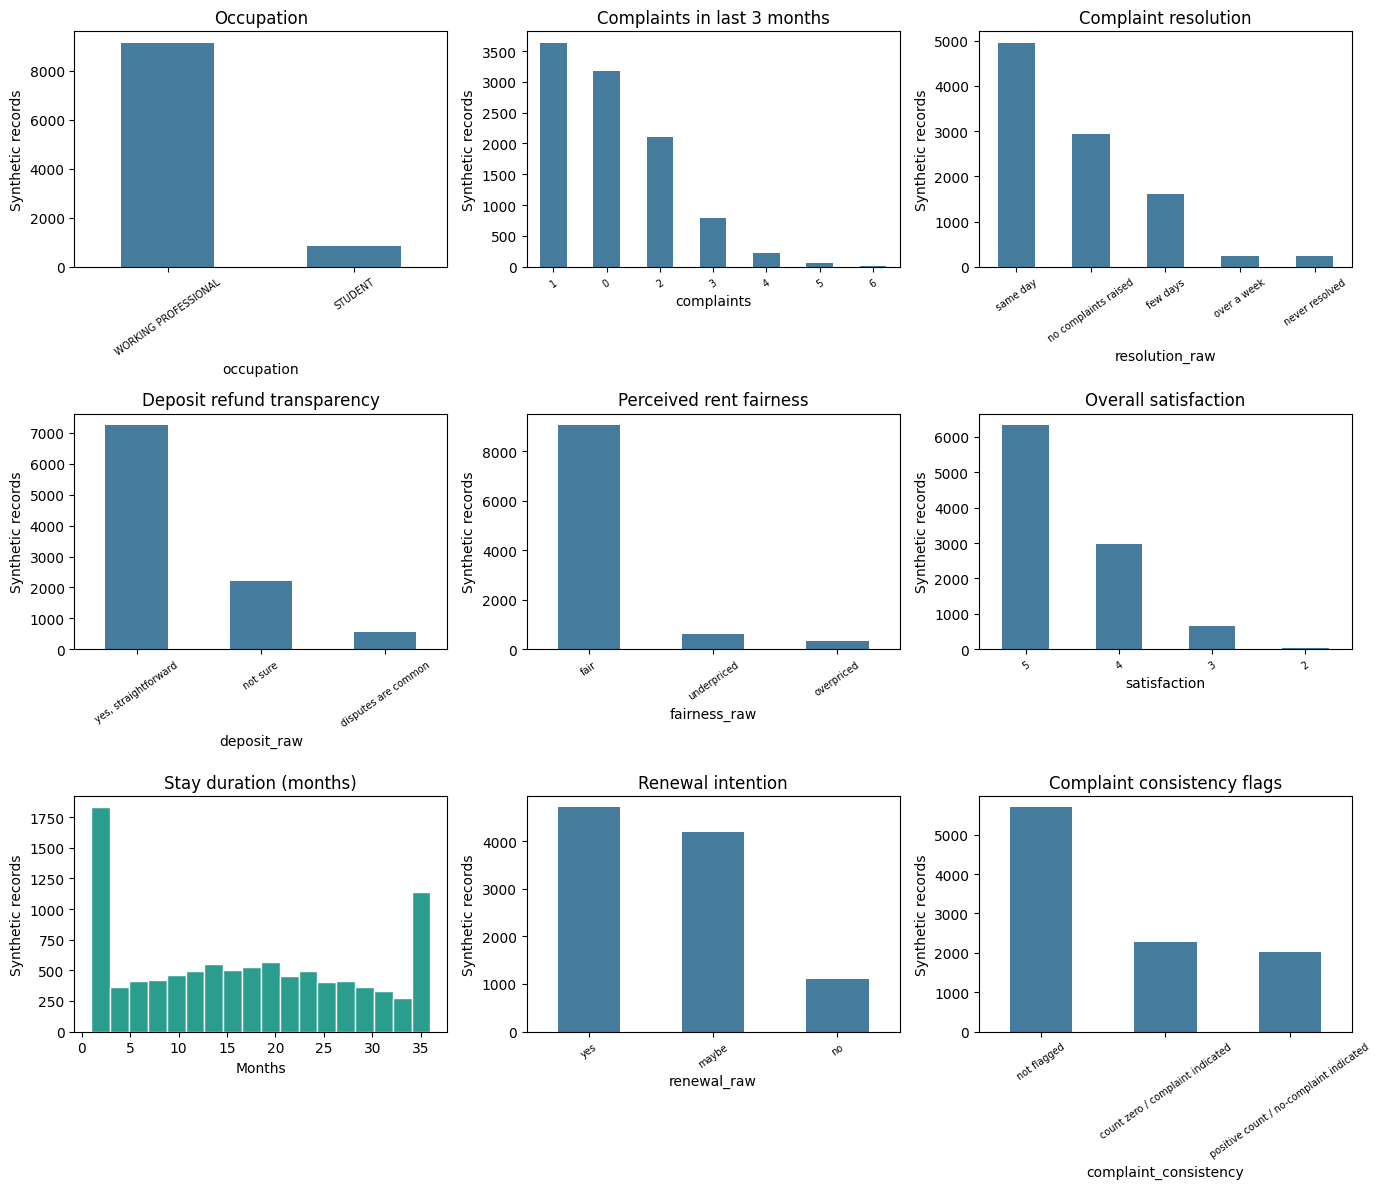

Interpretation: renewal intentions are distributed across Yes, Maybe and No; satisfaction is concentrated at 4?5; complaint counts and complaint-resolution consistency warrant operational data-quality review. These are properties of this synthetic file.


In [7]:
# Distributions for remaining survey fields; ordinal labels remain as recorded for readability.
fig,axs=plt.subplots(3,3,figsize=(14,12))
plot_specs=[
 ('occupation','Occupation'),('complaints','Complaints in last 3 months'),
 ('resolution_raw','Complaint resolution'),('deposit_raw','Deposit refund transparency'),
 ('fairness_raw','Perceived rent fairness'),('satisfaction','Overall satisfaction'),
 ('stay_months','Stay duration (months)'),('renewal_raw','Renewal intention'),('complaint_consistency','Complaint consistency flags')]
for ax,(col,title) in zip(axs.flat,plot_specs):
 if col in ['stay_months']:
  work[col].plot.hist(bins=18,ax=ax,color='#2a9d8f',edgecolor='white'); ax.set_xlabel('Months')
 else:
  work[col].value_counts(dropna=False).plot.bar(ax=ax,color='#457b9d'); ax.tick_params(axis='x',labelrotation=35,labelsize=7)
 ax.set_title(title); ax.set_ylabel('Synthetic records')
plt.tight_layout(); plt.show()
print('Interpretation: renewal intentions are distributed across Yes, Maybe and No; satisfaction is concentrated at 4?5; complaint counts and complaint-resolution consistency warrant operational data-quality review. These are properties of this synthetic file.')

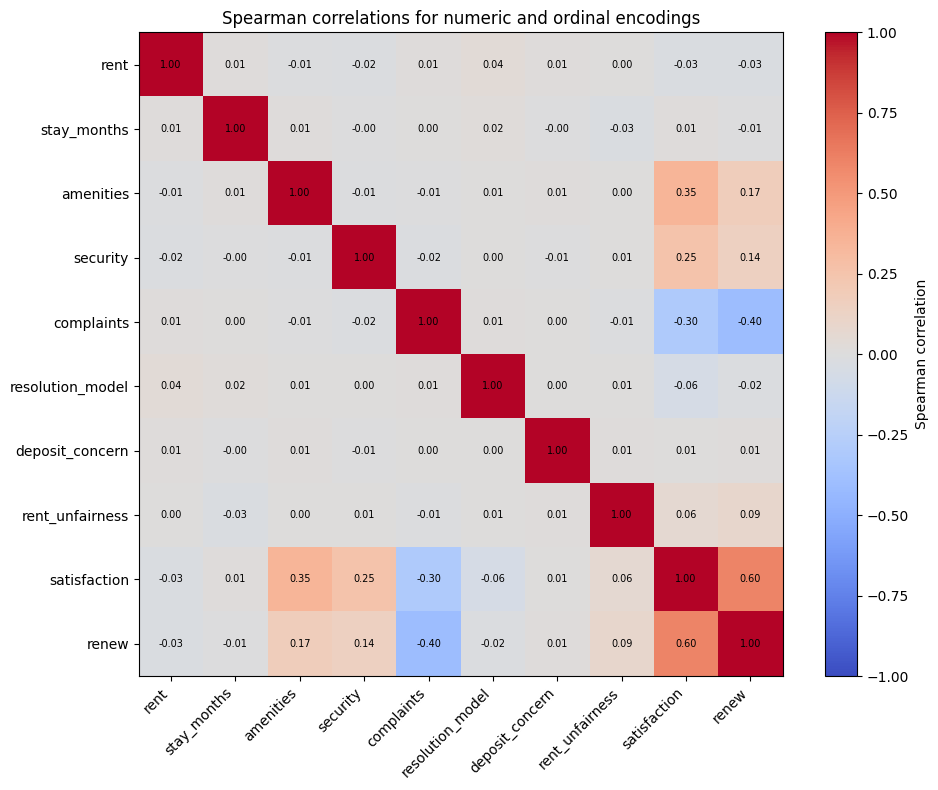

Interpretation: ordinal codes provide a compact descriptive comparison; category spacing is not assumed to be equal. Correlation does not imply causation, and synthetic generation may induce associations.


In [8]:
# Numeric/ordinal correlation heatmap on definite Yes/No rows.
heat_cols=['rent','stay_months','amenities','security','complaints','resolution_model','deposit_concern','rent_unfairness','satisfaction']
heat=model_df[heat_cols].copy(); heat['renew']=y.to_numpy()
corr=heat.corr(method='spearman')
fig,ax=plt.subplots(figsize=(10,8)); im=ax.imshow(corr,cmap='coolwarm',vmin=-1,vmax=1)
ax.set_xticks(range(len(corr.columns)),corr.columns,rotation=45,ha='right'); ax.set_yticks(range(len(corr.index)),corr.index)
for i in range(len(corr.index)):
 for j in range(len(corr.columns)): ax.text(j,i,f'{corr.iloc[i,j]:.2f}',ha='center',va='center',fontsize=7)
fig.colorbar(im,ax=ax,label='Spearman correlation'); ax.set_title('Spearman correlations for numeric and ordinal encodings')
plt.tight_layout(); plt.show()
print('Interpretation: ordinal codes provide a compact descriptive comparison; category spacing is not assumed to be equal. Correlation does not imply causation, and synthetic generation may induce associations.')

## 4. Statistical association tests

Mannâ€“Whitney U compares ordinal/numeric feature distributions between definite Yes and No groups; rank-biserial effect size is reported. Categorical features use chi-square association and CramÃ©râ€™s V. The 10,000 rows are synthetic and may be dependent on a small seed or programmed rules, so conventional p-values should not be interpreted as evidence from 10,000 independent observations.

In [9]:
def rank_biserial(x1,x0):
 u=mannwhitneyu(x1,x0,alternative='two-sided').statistic
 return 2*u/(len(x1)*len(x0))-1
def cramers_v(tab):
 chi=chi2_contingency(tab,correction=False)[0]; n=tab.to_numpy().sum(); r,k=tab.shape
 return np.sqrt(chi/(n*min(k-1,r-1))) if min(k-1,r-1)>0 else np.nan
test_rows=[]
for f in ['amenities','security','complaints','resolution_model','deposit_concern','rent_unfairness','satisfaction']:
 a=model_df.loc[y==1,f].dropna(); b=model_df.loc[y==0,f].dropna(); stat,p=mannwhitneyu(a,b,alternative='two-sided')
 test_rows.append([f,'Mannâ€“Whitney U',stat,p,rank_biserial(a,b)])
for f in ['occupation']:
 tab=pd.crosstab(model_df[f],y); chi,p,_,_=chi2_contingency(tab); test_rows.append([f,'Chi-square',chi,p,cramers_v(tab)])
tests=pd.DataFrame(test_rows,columns=['feature','test','statistic','p_value','effect_size'])
tests.round(4)

,feature,test,statistic,p_value,effect_size
0,amenities,Mannâ€“Whitney U,3.205818e+06,0.0000,0.2386
1,security,Mannâ€“Whitney U,3.080671e+06,0.0000,0.1902
2,complaints,Mannâ€“Whitney U,1.144582e+06,0.0000,-0.5578
3,resolution_model,Mannâ€“Whitney U,2.522000e+06,0.1497,-0.0256
4,deposit_concern,Mannâ€“Whitney U,2.614292e+06,0.5061,0.0100
5,rent_unfairness,Mannâ€“Whitney U,2.752602e+06,0.0000,0.0635
6,satisfaction,Mannâ€“Whitney U,4.396682e+06,0.0000,0.6987
7,occupation,Chi-square,2.867000e-01,0.5924,0.0078


## 5â€“6. Feature-block comparison and implementation

Logistic Regression and Random Forest are evaluated with 5-fold stratified cross-validation repeated 10 times (50 held-out folds). Imputation, scaling (for Logistic Regression), and model fitting occur inside each fold. We compare amenity-only, service-only and combined blocks. Satisfaction is deliberately outside the primary comparison and added only in a proxy/leakage experiment. Metrics are ROC-AUC, average precision, balanced accuracy and F1; majority-class accuracy is given as a naive reference. Cross-validation on synthetic rows can reflect synthesis rules rather than generalization to new residents.

In [10]:
cv=RepeatedStratifiedKFold(n_splits=5,n_repeats=10,random_state=SEED)
scoring={'roc_auc':'roc_auc','average_precision':'average_precision','balanced_accuracy':'balanced_accuracy','f1':'f1'}
def models():
 return {
  'Logistic Regression':Pipeline([('imputer',SimpleImputer(strategy='median')),('scale',StandardScaler()),('model',LogisticRegression(class_weight='balanced',max_iter=2000,random_state=SEED))]),
  'Random Forest':Pipeline([('imputer',SimpleImputer(strategy='median')),('model',RandomForestClassifier(n_estimators=80,min_samples_leaf=5,class_weight='balanced_subsample',random_state=SEED,n_jobs=1))])}
sets={'Amenity only':AMENITY,'Service only':BEHAVIOR,'Combined':CORE}
res=[]
for block,features in sets.items():
 X=model_df[features]
 for name,est in models().items():
  out=cross_validate(est,X,y,cv=cv,scoring=scoring,n_jobs=1)
  for metric in scoring:
   vals=out['test_'+metric]; res.append([block,name,metric,vals.mean(),vals.std(),np.quantile(vals,.025),np.quantile(vals,.975)])
metrics=pd.DataFrame(res,columns=['block','model','metric','mean','sd','q025','q975'])
metrics.round(3)

,block,model,metric,mean,sd,q025,q975
0,Amenity only,Logistic Regression,roc_auc,0.660,0.020,0.621,0.693
1,Amenity only,Logistic Regression,average_precision,0.875,0.009,0.859,0.889
2,Amenity only,Logistic Regression,balanced_accuracy,0.612,0.017,0.581,0.647
3,Amenity only,Logistic Regression,f1,0.785,0.010,0.769,0.804
4,Amenity only,Random Forest,roc_auc,0.654,0.019,0.620,0.679
5,Amenity only,Random Forest,average_precision,0.873,0.009,0.857,0.888
6,Amenity only,Random Forest,balanced_accuracy,0.609,0.014,0.580,0.634
7,Amenity only,Random Forest,f1,0.808,0.027,0.750,0.836
8,Service only,Logistic Regression,roc_auc,0.787,0.012,0.767,0.815
9,Service only,Logistic Regression,average_precision,0.923,0.007,0.914,0.937


In [11]:
# Baseline: always predict Yes on this definite Yes/No subset.
print('Majority class accuracy:',round(y.value_counts(normalize=True).max(),3),'; balanced accuracy = 0.5 by construction')
# Satisfaction proxy/leakage check, same repeated folds
leak=[]
for block,features in {'Combined':CORE,'Combined + satisfaction':CORE+['satisfaction']}.items():
 for name,est in models().items():
  out=cross_validate(est,model_df[features],y,cv=cv,scoring=scoring,n_jobs=1)
  leak.append([block,name,out['test_roc_auc'].mean(),out['test_roc_auc'].std(),out['test_average_precision'].mean()])
pd.DataFrame(leak,columns=['feature_set','model','ROC-AUC mean','ROC-AUC SD','Average precision mean']).round(3)

Majority class accuracy: 0.811 ; balanced accuracy = 0.5 by construction


,feature_set,model,ROC-AUC mean,ROC-AUC SD,Average precision mean
0,Combined,Logistic Regression,0.831,0.012,0.946
1,Combined,Random Forest,0.842,0.010,0.950
2,Combined + satisfaction,Logistic Regression,0.911,0.011,0.970
3,Combined + satisfaction,Random Forest,0.913,0.009,0.973


## Feature importance

Permutation importance is calculated on one stratified held-out split for the combined Random Forest, using ROC-AUC decrease. It is descriptive and may be unstable under correlated features and synthetic generation rules. A single split is not a definitive ranking.

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance
X=model_df[CORE]; Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=.25,stratify=y,random_state=SEED)
rf=models()['Random Forest'].fit(Xtr,ytr)
pi=permutation_importance(rf,Xte,yte,n_repeats=20,random_state=SEED,scoring='roc_auc',n_jobs=1)
importance=pd.DataFrame({'feature':CORE,'mean_auc_drop':pi.importances_mean,'sd':pi.importances_std}).sort_values('mean_auc_drop',ascending=False)
importance

,feature,mean_auc_drop,sd
3,complaints,0.223257,0.011345
0,amenities,0.047877,0.006433
5,rent_unfairness,0.037442,0.003622
1,security,0.029450,0.005923
2,resolution_model,0.008583,0.003288
4,deposit_concern,0.004666,0.002489


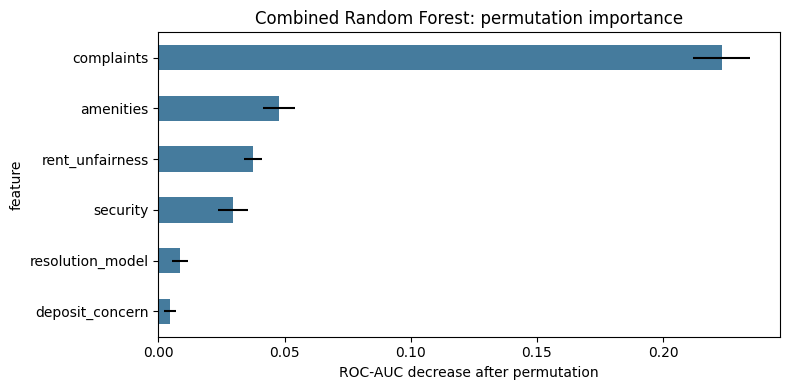

In [13]:
importance.sort_values('mean_auc_drop').plot.barh(x='feature',y='mean_auc_drop',xerr='sd',legend=False,figsize=(8,4),color='#457b9d'); plt.xlabel('ROC-AUC decrease after permutation'); plt.title('Combined Random Forest: permutation importance'); plt.tight_layout(); plt.show()

## 5. Comparison with State-of-the-Art Methods

| Study / year | Dataset | Method | Evaluation approach | Key result | Comparison |
|---|---|---|---|---|---|
| In (2024), commercial real estate renewal | Commercial real-estate tenant context; sample details not provided in accessible record | Examines management reliability, adequacy and tenant empathy against perceived value and renewal intention | Influence/hypothesis testing; numerical metric unavailable in record | All three service-quality factors positively related to perceived value and renewal intention | Similar renewal context; this case tests specific PG service features using predictive CV on synthetic records. |
| Marandi, Tasavori & Najmi (2023 online; 2024 issue), hotel revisit | About 100,000 TripAdvisor reviews from 100 hotels | Machine learning and text analysis; feature extraction and customer segmentation | Text feature/segment analysis; predictive score not provided in repository abstract | Extracted 71 features; room, staff, food and accessibility salient; identified 15 segments | Large real review corpus and revisit outcome; this case uses structured synthetic survey-style variables. |
| Park & Lee (2025), residential lease renewal | Online self-report survey in Busan; sample size not in accessible abstract | Hypothesis testing of location factors and mediation by residential satisfaction | Significance/mediation tests; numeric metrics not available in abstract | Location factors related to renewal; satisfaction mediated selected associations | Residential renewal relevance; this case compares PG service and amenity blocks. |

Studies differ in populations, outcomes and data. Their statistical results or performance cannot be ranked against this synthetic-file analysis. References: In (2024), https://doi.org/10.47116/apjcri.2024.08.16; Marandi et al. (2023/2024), https://doi.org/10.1108/IJCHM-06-2022-0719; Park & Lee (2025), https://doi.org/10.6106/KJCEM.2025.26.5.053.

## 7. Conclusion, limitations and recommendation

Interpret the generated-file patterns as exploratory. In particular, a strong metric on generated rows would not demonstrate reliable prediction for real PG residents. A practical next step is to validate service and amenity signals prospectively on a new, consented and anonymized sample, keeping â€œMaybeâ€ as its own outcome and collecting complaint resolution and deposit transparency consistently. Track actual renewal behavior separately from stated intention.

**Limitations:** the original source export and collection procedure are unavailable here; generation procedure and fidelity cannot be audited from the CSV alone; â€œMaybeâ€ is omitted from binary prediction; the synthetic records are not independent real respondents; no unexpected-charges field exists; cross-sectional self-report cannot support causal claims; ordinal coding imposes an ordering; and feature importance/model scores may encode synthesis rules. All results are conditional on the supplied file.